In [3]:
from torchvision import models
import torch.nn as nn
import copy
import time
import torch
import numpy as np
import random
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt 
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import torch.nn.functional as F
import random as _random

In [4]:
%run "2_3_dataset_transforms.ipynb"

C:\Users\Lenovo\Desktop\project 2\project2\14_resNet\newData\dataset\train -> True
C:\Users\Lenovo\Desktop\project 2\project2\14_resNet\newData\dataset\clean -> True
C:\Users\Lenovo\Desktop\project 2\project2\14_resNet\newData\datasetv2_TrainClean\train -> True
C:\Users\Lenovo\Desktop\project 2\project2\14_resNet\newData\datasetv2_TrainClean\clean -> True

 newData\dataset\train
Classes: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']

 newData\dataset\clean
Classes: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']

 newData\datasetv2_TrainClean\train
Classes: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']

 newData\datasetv2_TrainClean\clean
Classes: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
Total number of images: 3313

Number by class:
label
savari       498
kamyun       493
taxi         484
autobus      464
kamyunet     456
minibu

In [5]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

print("Seed:", seed)

Seed: 42


# 4.1 — load pretrained ResNet18 and inspect its structure

In [6]:
base_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
print(base_model.fc)
print(f"\nTotal parameters: {sum(p.numel() for p in base_model.parameters()):,}")

Linear(in_features=512, out_features=1000, bias=True)

Total parameters: 11,689,512


# 4.2 — function to build a ResNet18 model (for either feature extraction or fine-tuning)

In [7]:
def build_resnet18(num_classes, mode="feature_extraction"):
    """
    mode = "feature_extraction": فریز تمام لایه‌های کانولوشنی،آموزش فقط لایه نهایی جدید.  
    mode = "fine_tuning": آموزش کل شبکه
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if mode == "feature_extraction":
        for param in model.parameters():
            param.requires_grad = False
    elif mode == "fine_tuning":
        for param in model.parameters():
            param.requires_grad = True
    else:
        raise ValueError(f"Unknown mode: {mode}")

    in_features = model.fc.in_features     #جایگزین لایه نهایی
    model.fc = nn.Linear(in_features, num_classes)

    return model

# 4.3 — build the feature extraction version of the coarse model and verify trainable parameters

In [8]:
NUM_COARSE_CLASSES = len(COARSE_CLASS_TO_IDX)

coarse_model_fe = build_resnet18(NUM_COARSE_CLASSES, mode="feature_extraction")
coarse_model_fe = coarse_model_fe.to(DEVICE)

trainable_params = sum(p.numel() for p in coarse_model_fe.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in coarse_model_fe.parameters())

print(f"Feature extraction mode")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable ratio: {trainable_params / total_params:.4%}") #پارامترهای قابل آموزش لایه fc

Feature extraction mode
Trainable parameters: 3,591
Total parameters: 11,180,103
Trainable ratio: 0.0321%


# 4.4 — general-purpose training and validation function

In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    best_model_weights = copy.deepcopy(model.state_dict())
    best_val_accuracy = 0.0

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
    }
    for epoch in range(num_epochs):
        epoch_start = time.time()

        # Training phase
        model.train()
        running_loss = 0.0
        running_correct = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += torch.sum(preds == labels).item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_correct / len(train_loader.dataset)

        # Validation phase
        model.eval()
        running_loss = 0.0
        running_correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                running_correct += torch.sum(preds == labels).item()

        val_loss = running_loss / len(val_loader.dataset)
        val_acc = running_correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch+1}/{num_epochs} "
              f"[{epoch_time:.1f}s] "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    print(f"\nBest validation accuracy: {best_val_accuracy:.4f}")
    model.load_state_dict(best_model_weights)
    return model, history

# 4.5 — train the coarse model (feature extraction mode)

In [9]:
NUM_EPOCHS_FE = 10
LEARNING_RATE_FE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer_fe = torch.optim.Adam(coarse_model_fe.parameters(), lr=LEARNING_RATE_FE)

coarse_model_fe, history_fe = train_model(
    coarse_model_fe,
    coarse_train_loader,
    coarse_val_loader,
    criterion,
    optimizer_fe,
    num_epochs=NUM_EPOCHS_FE,
    device=DEVICE,
)

Epoch 1/10 [61.3s] train_loss=1.2617 train_acc=0.5940 val_loss=0.8143 val_acc=0.7786
Epoch 2/10 [70.9s] train_loss=0.7362 train_acc=0.7930 val_loss=0.6168 val_acc=0.8554
Epoch 3/10 [80.5s] train_loss=0.5830 train_acc=0.8366 val_loss=0.4885 val_acc=0.8494
Epoch 4/10 [74.3s] train_loss=0.5066 train_acc=0.8525 val_loss=0.4156 val_acc=0.8750
Epoch 5/10 [93.3s] train_loss=0.4668 train_acc=0.8571 val_loss=0.4291 val_acc=0.8675
Epoch 6/10 [127.4s] train_loss=0.4253 train_acc=0.8734 val_loss=0.3732 val_acc=0.8976
Epoch 7/10 [88.3s] train_loss=0.3942 train_acc=0.8783 val_loss=0.3609 val_acc=0.8825
Epoch 8/10 [84.9s] train_loss=0.3684 train_acc=0.8870 val_loss=0.3573 val_acc=0.8795
Epoch 9/10 [86.7s] train_loss=0.3588 train_acc=0.8920 val_loss=0.3305 val_acc=0.8931
Epoch 10/10 [81.7s] train_loss=0.3497 train_acc=0.8889 val_loss=0.3144 val_acc=0.9111

Best validation accuracy: 0.9111


# 4.6 — save the best feature extraction model to disk

In [12]:
MODELS_DIR = BASE_DIR.parent / "saved_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "coarse_resnet18_feature_extraction.pt"
torch.save(coarse_model_fe.state_dict(), model_path)

print(f"Model saved to: {model_path}")

Model saved to: saved_models\coarse_resnet18_feature_extraction.pt


# 4.7 — build the fine tuning version of the coarse model

In [13]:
coarse_model_ft = build_resnet18(NUM_COARSE_CLASSES, mode="fine_tuning")
coarse_model_ft = coarse_model_ft.to(DEVICE)

trainable_params = sum(p.numel() for p in coarse_model_ft.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in coarse_model_ft.parameters())

print(f"Fine-tuning mode")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable ratio: {trainable_params / total_params:.4%}")

Fine-tuning mode
Trainable parameters: 11,180,103
Total parameters: 11,180,103
Trainable ratio: 100.0000%


# 4.8 — build optimizer with separate learning rates for backbone and final layer

In [14]:
BACKBONE_LR = 0.0001
HEAD_LR = 0.001

backbone_params = [
    param for name, param in coarse_model_ft.named_parameters()
    if not name.startswith("fc.")
]
head_params = [
    param for name, param in coarse_model_ft.named_parameters()
    if name.startswith("fc.")
]
optimizer_ft = torch.optim.Adam([
    {"params": backbone_params, "lr": BACKBONE_LR},
    {"params": head_params, "lr": HEAD_LR},
])
print(f"Backbone parameters: {sum(p.numel() for p in backbone_params):,} at lr={BACKBONE_LR}")
print(f"Head (fc) parameters: {sum(p.numel() for p in head_params):,} at lr={HEAD_LR}")

Backbone parameters: 11,176,512 at lr=0.0001
Head (fc) parameters: 3,591 at lr=0.001


# 4.9 — train the coarse model (fine tuning mode)

In [15]:
NUM_EPOCHS_FT = 8
criterion = nn.CrossEntropyLoss()

coarse_model_ft, history_ft = train_model(
    coarse_model_ft,
    coarse_train_loader,
    coarse_val_loader,
    criterion,
    optimizer_ft,
    num_epochs=NUM_EPOCHS_FT,
    device=DEVICE,
)

Epoch 1/8 [185.9s] train_loss=0.3997 train_acc=0.8787 val_loss=0.0817 val_acc=0.9774
Epoch 2/8 [180.4s] train_loss=0.0809 train_acc=0.9807 val_loss=0.0776 val_acc=0.9729
Epoch 3/8 [178.4s] train_loss=0.0443 train_acc=0.9875 val_loss=0.0708 val_acc=0.9744
Epoch 4/8 [180.6s] train_loss=0.0302 train_acc=0.9901 val_loss=0.0396 val_acc=0.9880
Epoch 5/8 [181.1s] train_loss=0.0184 train_acc=0.9955 val_loss=0.0390 val_acc=0.9864
Epoch 6/8 [187.0s] train_loss=0.0215 train_acc=0.9939 val_loss=0.0348 val_acc=0.9880
Epoch 7/8 [178.9s] train_loss=0.0126 train_acc=0.9970 val_loss=0.0305 val_acc=0.9880
Epoch 8/8 [178.3s] train_loss=0.0181 train_acc=0.9947 val_loss=0.0339 val_acc=0.9834

Best validation accuracy: 0.9880


# 5.1 — save the best fine tuning model to disk

In [16]:
model_path = MODELS_DIR / "coarse_resnet18_fine_tuning.pt"
torch.save(coarse_model_ft.state_dict(), model_path)

print(f"Model saved to: {model_path}")

Model saved to: saved_models\coarse_resnet18_fine_tuning.pt


# 5.2 — compute class weights from the coarse training distribution

In [17]:
coarse_train_counts = train_df["coarse_label"].value_counts().sort_index()

counts_ordered = np.array([
    coarse_train_counts[COARSE_IDX_TO_CLASS[i]] for i in range(NUM_COARSE_CLASSES)
])

total_samples = counts_ordered.sum()
class_weights = total_samples / (NUM_COARSE_CLASSES * counts_ordered)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class counts and computed weights:")
for i in range(NUM_COARSE_CLASSES):
    print(f"  {COARSE_IDX_TO_CLASS[i]:15s} count={counts_ordered[i]:4d}  weight={class_weights[i]:.4f}")

Class counts and computed weights:
  ambulance       count= 288  weight=1.3085
  autobus         count= 370  weight=1.0185
  minibus         count= 313  weight=1.2040
  savari          count= 398  weight=0.9469
  taxi            count= 387  weight=0.9738
  truck_merged    count= 758  weight=0.4972
  vanet           count= 124  weight=3.0392


In [ ]:
# کمترین تعداد ---> بیشترین وزن
# بیشترین تعداد ---> کمترین وزن

# 5.3 — run inference on the validation set and collect predictions

In [18]:
def get_predictions(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

val_true, val_pred = get_predictions(coarse_model_ft, coarse_val_loader, DEVICE)
print(f"Total validation samples evaluated: {len(val_true)}")

Total validation samples evaluated: 664


# 5.4 — per-class  precision, recall, f1 score, confusion matrix

In [24]:
class_names_ordered = [COARSE_IDX_TO_CLASS[i] for i in range(NUM_COARSE_CLASSES)]

report = classification_report(val_true, val_pred, target_names=class_names_ordered, digits=4)

print("Classification report (fine-tuned coarse model, validation set):\n")
print(report)

cm = confusion_matrix(val_true, val_pred)

print("Confusion matrix (rows = true label, columns = predicted label):\n")
print("Class order:", class_names_ordered)
print('\n',cm)

Classification report (fine-tuned coarse model, validation set):

              precision    recall  f1-score   support

   ambulance     0.9730    0.9863    0.9796        73
     autobus     0.9892    0.9892    0.9892        93
     minibus     0.9873    0.9873    0.9873        79
      savari     0.9804    1.0000    0.9901       100
        taxi     1.0000    1.0000    1.0000        97
truck_merged     0.9895    0.9843    0.9869       191
       vanet     1.0000    0.9355    0.9667        31

    accuracy                         0.9880       664
   macro avg     0.9885    0.9832    0.9857       664
weighted avg     0.9880    0.9880    0.9879       664

Confusion matrix (rows = true label, columns = predicted label):

Class order: ['ambulance', 'autobus', 'minibus', 'savari', 'taxi', 'truck_merged', 'vanet']

 [[ 72   0   0   1   0   0   0]
 [  0  92   0   0   0   1   0]
 [  0   0  78   0   0   1   0]
 [  0   0   0 100   0   0   0]
 [  0   0   0   0  97   0   0]
 [  1   1   1   0   0 

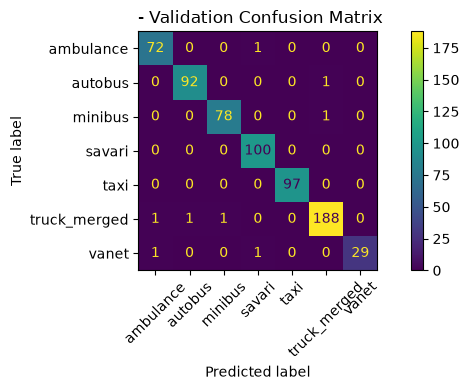

In [27]:
classes = [
    'ambulance',
    'autobus',
    'minibus',
    'savari',
    'taxi',
    'truck_merged',
    'vanet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 4))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title(" - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

--- 

# experiments:

## Weighted Loss

### 1.1 — Build a fresh fine-tuning model for the weighted-loss experiment

In [28]:
coarse_model_ft_weighted = build_resnet18(NUM_COARSE_CLASSES, mode="fine_tuning")
coarse_model_ft_weighted = coarse_model_ft_weighted.to(DEVICE)

backbone_params_w = [
    param for name, param in coarse_model_ft_weighted.named_parameters()
    if not name.startswith("fc.")
]
head_params_w = [
    param for name, param in coarse_model_ft_weighted.named_parameters()
    if name.startswith("fc.")
]
optimizer_ft_weighted = torch.optim.Adam([
    {"params": backbone_params_w, "lr": BACKBONE_LR},
    {"params": head_params_w, "lr": HEAD_LR},
])
print("Fresh fine-tuning model built for the weighted-loss experiment.")

Fresh fine-tuning model built for the weighted-loss experiment.


### 1.2 — Train with class-weighted CrossEntropyLoss

In [29]:
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights_tensor)

coarse_model_ft_weighted, history_ft_weighted = train_model(
    coarse_model_ft_weighted,
    coarse_train_loader,
    coarse_val_loader,
    criterion_weighted,
    optimizer_ft_weighted,
    num_epochs=NUM_EPOCHS_FT,
    device=DEVICE,
)

Epoch 1/8 [165.5s] train_loss=0.4841 train_acc=0.8457 val_loss=0.1330 val_acc=0.9563
Epoch 2/8 [255.1s] train_loss=0.0989 train_acc=0.9689 val_loss=0.0777 val_acc=0.9759
Epoch 3/8 [276.8s] train_loss=0.0414 train_acc=0.9890 val_loss=0.0487 val_acc=0.9849
Epoch 4/8 [314.0s] train_loss=0.0261 train_acc=0.9939 val_loss=0.0472 val_acc=0.9819
Epoch 5/8 [198.8s] train_loss=0.0349 train_acc=0.9898 val_loss=0.0274 val_acc=0.9880
Epoch 6/8 [228.9s] train_loss=0.0253 train_acc=0.9917 val_loss=0.0455 val_acc=0.9834
Epoch 7/8 [243.7s] train_loss=0.0244 train_acc=0.9924 val_loss=0.0308 val_acc=0.9910
Epoch 8/8 [179.5s] train_loss=0.0118 train_acc=0.9966 val_loss=0.0323 val_acc=0.9880

Best validation accuracy: 0.9910


### 1.3 — Evaluate the weighted model per-class and compare to baseline

In [30]:
val_true_w, val_pred_w = get_predictions(coarse_model_ft_weighted, coarse_val_loader, DEVICE)

report_weighted = classification_report(
    val_true_w, val_pred_w,
    target_names=class_names_ordered,
    digits=4,
)

print("Classification report (fine-tuned coarse model WITH class weights):\n")
print(report_weighted)

cm_weighted = confusion_matrix(val_true_w, val_pred_w)
print("\nConfusion matrix (rows = true label, columns = predicted label):\n")
print("Class order:", class_names_ordered)
print()
print(cm_weighted)

Classification report (fine-tuned coarse model WITH class weights):

              precision    recall  f1-score   support

   ambulance     1.0000    0.9589    0.9790        73
     autobus     1.0000    0.9892    0.9946        93
     minibus     0.9875    1.0000    0.9937        79
      savari     1.0000    1.0000    1.0000       100
        taxi     0.9898    1.0000    0.9949        97
truck_merged     0.9895    0.9895    0.9895       191
       vanet     0.9394    1.0000    0.9688        31

    accuracy                         0.9910       664
   macro avg     0.9866    0.9911    0.9886       664
weighted avg     0.9912    0.9910    0.9910       664


Confusion matrix (rows = true label, columns = predicted label):

Class order: ['ambulance', 'autobus', 'minibus', 'savari', 'taxi', 'truck_merged', 'vanet']

[[ 70   0   0   0   0   1   2]
 [  0  92   0   0   0   1   0]
 [  0   0  79   0   0   0   0]
 [  0   0   0 100   0   0   0]
 [  0   0   0   0  97   0   0]
 [  0   0   1   0  

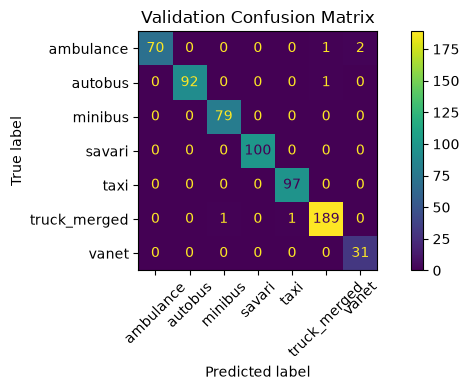

In [33]:
classes = [
    'ambulance',
    'autobus',
    'minibus',
    'savari',
    'taxi',
    'truck_merged',
    'vanet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_weighted,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 4))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

### 1.4 — Save the weighted model to disk

In [34]:
model_path = MODELS_DIR / "coarse_resnet18_fine_tuning_weighted.pt"
torch.save(coarse_model_ft_weighted.state_dict(), model_path)

print(f"Model saved to: {model_path}")

Model saved to: saved_models\coarse_resnet18_fine_tuning_weighted.pt


---

## Balanced Batch Sampler

### 2.1 Compute per-sample weights using WeightedRandomSampler

In [37]:
class_counts = train_df["coarse_label"].value_counts()
print("Class counts:\n", class_counts)

class_weights_sampler = {
    class_name: 1.0 / count
    for class_name, count in class_counts.items()
}
print("\nPer-class sampling weights:\n", class_weights_sampler)

sample_weights = train_df["coarse_label"].map(class_weights_sampler).values
sample_weights = torch.DoubleTensor(sample_weights)

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

Class counts:
 coarse_label
truck_merged    758
savari          398
taxi            387
autobus         370
minibus         313
ambulance       288
vanet           124
Name: count, dtype: int64

Per-class sampling weights:
 {'truck_merged': 0.0013192612137203166, 'savari': 0.002512562814070352, 'taxi': 0.002583979328165375, 'autobus': 0.002702702702702703, 'minibus': 0.003194888178913738, 'ambulance': 0.003472222222222222, 'vanet': 0.008064516129032258}


### 2.2 — Build a dataloader using the weighted sampler and verify the resulting batch balance

In [38]:
coarse_train_loader_balanced = DataLoader(
    coarse_train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,  # sampler replaces shuffle=True
    num_workers=NUM_WORKERS,
)
# بررسی توزیع کلاس‌ها در چند دسته 

batch_counter = Counter()
batch_iter = iter(coarse_train_loader_balanced)
for _ in range(10):
    images, labels = next(batch_iter)
    for label_idx in labels.numpy():
        batch_counter[COARSE_IDX_TO_CLASS[label_idx]] += 1

print("Class distribution across 10 sample batches (should be roughly balanced):")
for class_name, count in batch_counter.items():
    print(f"  {class_name:15s}: {count}")

Class distribution across 10 sample batches (should be roughly balanced):
  ambulance      : 43
  autobus        : 51
  taxi           : 57
  savari         : 52
  truck_merged   : 44
  vanet          : 40
  minibus        : 33


### 2.3 — Creating a new model via fine-tuning and training with a balanced sampler

In [39]:
coarse_model_ft_balanced = build_resnet18(NUM_COARSE_CLASSES, mode="fine_tuning")
coarse_model_ft_balanced = coarse_model_ft_balanced.to(DEVICE)

backbone_params_b = [
    param for name, param in coarse_model_ft_balanced.named_parameters()
    if not name.startswith("fc.")
]
head_params_b = [
    param for name, param in coarse_model_ft_balanced.named_parameters()
    if name.startswith("fc.")
]
optimizer_ft_balanced = torch.optim.Adam([
    {"params": backbone_params_b, "lr": BACKBONE_LR},
    {"params": head_params_b, "lr": HEAD_LR},
])
criterion_plain = nn.CrossEntropyLoss()

coarse_model_ft_balanced, history_ft_balanced = train_model(
    coarse_model_ft_balanced,
    coarse_train_loader_balanced,
    coarse_val_loader,
    criterion_plain,
    optimizer_ft_balanced,
    num_epochs=NUM_EPOCHS_FT,
    device=DEVICE,
)

Epoch 1/8 [236.9s] train_loss=0.4453 train_acc=0.8567 val_loss=0.1239 val_acc=0.9654
Epoch 2/8 [286.6s] train_loss=0.0764 train_acc=0.9773 val_loss=0.0846 val_acc=0.9789
Epoch 3/8 [343.0s] train_loss=0.0419 train_acc=0.9898 val_loss=0.0537 val_acc=0.9804
Epoch 4/8 [232.1s] train_loss=0.0296 train_acc=0.9917 val_loss=0.0661 val_acc=0.9774
Epoch 5/8 [163.6s] train_loss=0.0179 train_acc=0.9939 val_loss=0.0364 val_acc=0.9849
Epoch 6/8 [160.6s] train_loss=0.0125 train_acc=0.9973 val_loss=0.0349 val_acc=0.9880
Epoch 7/8 [161.0s] train_loss=0.0160 train_acc=0.9951 val_loss=0.0339 val_acc=0.9864
Epoch 8/8 [161.3s] train_loss=0.0179 train_acc=0.9939 val_loss=0.0372 val_acc=0.9880

Best validation accuracy: 0.9880


### 2.4 — Evaluate the balanced-sampler model per-class

In [40]:
val_true_b, val_pred_b = get_predictions(coarse_model_ft_balanced, coarse_val_loader, DEVICE)

report_balanced = classification_report(
    val_true_b, val_pred_b,
    target_names=class_names_ordered,
    digits=4,
)
print("Classification report (fine-tuned coarse model WITH balanced sampler):\n")
print(report_balanced)

cm_balanced = confusion_matrix(val_true_b, val_pred_b)
print("\nConfusion matrix (rows = true label, columns = predicted label):\n")
print("Class order:", class_names_ordered)
print()
print(cm_balanced)

Classification report (fine-tuned coarse model WITH balanced sampler):

              precision    recall  f1-score   support

   ambulance     1.0000    0.9863    0.9931        73
     autobus     1.0000    0.9892    0.9946        93
     minibus     0.9750    0.9873    0.9811        79
      savari     0.9802    0.9900    0.9851       100
        taxi     0.9898    1.0000    0.9949        97
truck_merged     0.9895    0.9895    0.9895       191
       vanet     0.9667    0.9355    0.9508        31

    accuracy                         0.9880       664
   macro avg     0.9859    0.9826    0.9842       664
weighted avg     0.9880    0.9880    0.9879       664


Confusion matrix (rows = true label, columns = predicted label):

Class order: ['ambulance', 'autobus', 'minibus', 'savari', 'taxi', 'truck_merged', 'vanet']

[[ 72   0   0   0   0   0   1]
 [  0  92   0   0   0   1   0]
 [  0   0  78   0   0   1   0]
 [  0   0   0  99   1   0   0]
 [  0   0   0   0  97   0   0]
 [  0   0   2   

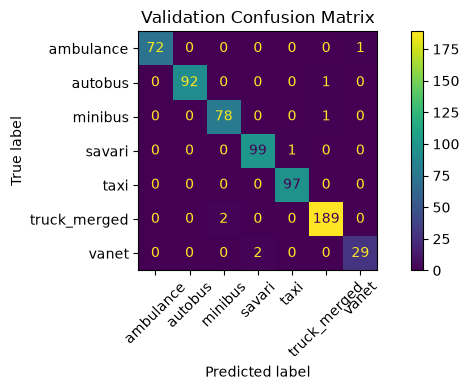

In [41]:
classes = [
    'ambulance',
    'autobus',
    'minibus',
    'savari',
    'taxi',
    'truck_merged',
    'vanet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 4))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

### 2.5 — Save the balanced-sampler model to disk

In [42]:
model_path = MODELS_DIR / "coarse_resnet18_fine_tuning_balanced.pt"
torch.save(coarse_model_ft_balanced.state_dict(), model_path)
print(f"Model saved to: {model_path}")

Model saved to: saved_models\coarse_resnet18_fine_tuning_balanced.pt


---

# Dataset Creation and `Cascade` Model (Second Stage)

### 3.1 — Filter the original (pre-merge) split into a kamyun/kamyunet-only subset

In [43]:
cascade_df = inventory_split_df[
    inventory_split_df["label"].isin(["kamyun", "kamyunet"])
].reset_index(drop=True)

print("Cascade subset size:", len(cascade_df))
print("\nClass counts by split:")
print(cascade_df.groupby(["split", "label"]).size())

Cascade subset size: 949

Class counts by split:
split  label   
train  kamyun      394
       kamyunet    364
val    kamyun       99
       kamyunet     92
dtype: int64


### 3.2 — Fixed class-to-index mapping for the cascade model

In [44]:
CASCADE_CLASS_NAMES = sorted(cascade_df["label"].unique())
CASCADE_CLASS_TO_IDX = {name: idx for idx, name in enumerate(CASCADE_CLASS_NAMES)}
CASCADE_IDX_TO_CLASS = {idx: name for name, idx in CASCADE_CLASS_TO_IDX.items()}

print("Cascade class to index mapping:")
for name, idx in CASCADE_CLASS_TO_IDX.items():
    print(f"  {name}: {idx}")

Cascade class to index mapping:
  kamyun: 0
  kamyunet: 1


### 3.3 — Build cascade train/val datasets and dataloaders

In [45]:
cascade_train_df = cascade_df[cascade_df["split"] == "train"].reset_index(drop=True)
cascade_val_df = cascade_df[cascade_df["split"] == "val"].reset_index(drop=True)

cascade_train_dataset = VehicleDataset(
    cascade_train_df, CASCADE_CLASS_TO_IDX, label_col="label", transform=train_transform
)
cascade_val_dataset = VehicleDataset(
    cascade_val_df, CASCADE_CLASS_TO_IDX, label_col="label", transform=val_transform
)
cascade_train_loader = DataLoader(
    cascade_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
cascade_val_loader = DataLoader(
    cascade_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print(f"Cascade train dataset size: {len(cascade_train_dataset)}")
print(f"Cascade validation dataset size: {len(cascade_val_dataset)}")

images, labels = next(iter(cascade_train_loader))
print(f"\nSample batch image shape: {images.shape}")
print(f"Sample batch label shape: {labels.shape}")
print(f"Label value range: min={labels.min().item()}, max={labels.max().item()}")

Cascade train dataset size: 758
Cascade validation dataset size: 191

Sample batch image shape: torch.Size([32, 3, 224, 224])
Sample batch label shape: torch.Size([32])
Label value range: min=0, max=1


## Cascade Model Training

### 3.4 — Build and fine-tune a ResNet18 model for the cascade (kamyun vs kamyunet)

In [46]:
NUM_CASCADE_CLASSES = len(CASCADE_CLASS_TO_IDX)

cascade_model = build_resnet18(NUM_CASCADE_CLASSES, mode="fine_tuning")
cascade_model = cascade_model.to(DEVICE)

backbone_params_c = [
    param for name, param in cascade_model.named_parameters()
    if not name.startswith("fc.")
]
head_params_c = [
    param for name, param in cascade_model.named_parameters()
    if name.startswith("fc.")
]

optimizer_cascade = torch.optim.Adam([
    {"params": backbone_params_c, "lr": BACKBONE_LR},
    {"params": head_params_c, "lr": HEAD_LR},
])

criterion_cascade = nn.CrossEntropyLoss()

cascade_model, history_cascade = train_model(
    cascade_model,
    cascade_train_loader,
    cascade_val_loader,
    criterion_cascade,
    optimizer_cascade,
    num_epochs=NUM_EPOCHS_FT,
    device=DEVICE,
)

Epoch 1/8 [61.1s] train_loss=0.4128 train_acc=0.7982 val_loss=0.3721 val_acc=0.8848
Epoch 2/8 [45.6s] train_loss=0.1757 train_acc=0.9288 val_loss=0.3146 val_acc=0.8639
Epoch 3/8 [61.9s] train_loss=0.1887 train_acc=0.9261 val_loss=0.3189 val_acc=0.8743
Epoch 4/8 [59.4s] train_loss=0.0735 train_acc=0.9749 val_loss=0.3987 val_acc=0.9058
Epoch 5/8 [93.1s] train_loss=0.0804 train_acc=0.9617 val_loss=0.3548 val_acc=0.9005
Epoch 6/8 [62.9s] train_loss=0.0455 train_acc=0.9855 val_loss=0.3871 val_acc=0.8848
Epoch 7/8 [79.4s] train_loss=0.0356 train_acc=0.9908 val_loss=0.2355 val_acc=0.9319
Epoch 8/8 [42.0s] train_loss=0.0242 train_acc=0.9934 val_loss=0.2384 val_acc=0.9319

Best validation accuracy: 0.9319


### 3.5 — Evaluate the cascade model per-class

In [47]:
cascade_class_names_ordered = [CASCADE_IDX_TO_CLASS[i] for i in range(NUM_CASCADE_CLASSES)]

val_true_cascade, val_pred_cascade = get_predictions(cascade_model, cascade_val_loader, DEVICE)

report_cascade = classification_report(
    val_true_cascade, val_pred_cascade,
    target_names=cascade_class_names_ordered,
    digits=4,
)

print("Classification report (cascade model: kamyun vs kamyunet):\n")
print(report_cascade)

cm_cascade = confusion_matrix(val_true_cascade, val_pred_cascade)
print("\nConfusion matrix (rows = true label, columns = predicted label):\n")
print("Class order:", cascade_class_names_ordered)
print()
print(cm_cascade)

Classification report (cascade model: kamyun vs kamyunet):

              precision    recall  f1-score   support

      kamyun     0.9886    0.8788    0.9305        99
    kamyunet     0.8835    0.9891    0.9333        92

    accuracy                         0.9319       191
   macro avg     0.9361    0.9340    0.9319       191
weighted avg     0.9380    0.9319    0.9319       191


Confusion matrix (rows = true label, columns = predicted label):

Class order: ['kamyun', 'kamyunet']

[[87 12]
 [ 1 91]]


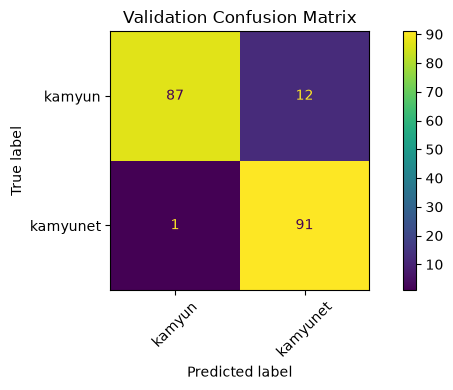

In [49]:
classes = [
    'kamyun',
    'kamyunet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cascade,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 4))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

### 3.6 — Save the cascade model to disk

In [50]:
model_path = MODELS_DIR / "cascade_resnet18_kamyun_kamyunet.pt"
torch.save(cascade_model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

Model saved to: saved_models\cascade_resnet18_kamyun_kamyunet.pt


---

### 4.1 — Combined inference function: coarse model, then cascade when needed

In [10]:
def predict_vehicle(image, coarse_model, cascade_model, coarse_idx_to_class,
                     cascade_idx_to_class, transform, device):
    """
    خط لوله کاملِ دو مرحله‌ای را روی یک تصویر PIL 
    اجرا کرده و پیش‌بینی نهایی ۸-کلاسه را به همراه امتیاز اطمینان ترکیبی بازمی‌گرداند. 

    image: یک شیء PIL.Image (با فرمت RGB)
    خروجی: یک دیکشنری شامل کلاس پیش‌بینی‌شده، میزان اطمینان و احتمالات میانی.
    """
    coarse_model.eval()
    cascade_model.eval()

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        coarse_logits = coarse_model(input_tensor)
        coarse_probs = F.softmax(coarse_logits, dim=1).squeeze(0).cpu().numpy()

    coarse_pred_idx = int(coarse_probs.argmax())
    coarse_pred_class = coarse_idx_to_class[coarse_pred_idx]
    coarse_confidence = float(coarse_probs[coarse_pred_idx])

    result = {
        "coarse_prediction": coarse_pred_class,
        "coarse_probs": {coarse_idx_to_class[i]: float(p) for i, p in enumerate(coarse_probs)},
    }

    if coarse_pred_class != "truck_merged":
        result["predicted_class"] = coarse_pred_class
        result["confidence"] = coarse_confidence
        result["cascade_probs"] = None
        return result

    # cascade model
    with torch.no_grad():
        cascade_logits = cascade_model(input_tensor)
        cascade_probs = F.softmax(cascade_logits, dim=1).squeeze(0).cpu().numpy()

    cascade_pred_idx = int(cascade_probs.argmax())
    cascade_pred_class = cascade_idx_to_class[cascade_pred_idx]
    cascade_confidence = float(cascade_probs[cascade_pred_idx])

    final_confidence = coarse_confidence * cascade_confidence

    result["predicted_class"] = cascade_pred_class
    result["confidence"] = final_confidence
    result["cascade_probs"] = {cascade_idx_to_class[i]: float(p) for i, p in enumerate(cascade_probs)}
    return result

### 4.2 — Sanity check on a handful of validation images spanning different classes

In [54]:
sample_rows = val_df.sample(n=8, random_state=SPLIT_SEED)
for _, row in sample_rows.iterrows():
    img = Image.open(row["filepath"]).convert("RGB")
    pred = predict_vehicle(
        img,
        coarse_model_ft_weighted,
        cascade_model,
        COARSE_IDX_TO_CLASS,
        CASCADE_IDX_TO_CLASS,
        val_transform,
        DEVICE,
    )
    match = "OK" if pred["predicted_class"] == row["label"] else "MISMATCH"
    print(f"[{match}] true={row['label']:12s} predicted={pred['predicted_class']:12s} "
          f"confidence={pred['confidence']:.4f}")

[OK] true=kamyun       predicted=kamyun       confidence=0.9999
[OK] true=kamyunet     predicted=kamyunet     confidence=0.9996
[OK] true=kamyun       predicted=kamyun       confidence=0.9992
[OK] true=autobus      predicted=autobus      confidence=1.0000
[OK] true=autobus      predicted=autobus      confidence=0.9918
[OK] true=savari       predicted=savari       confidence=0.9995
[OK] true=taxi         predicted=taxi         confidence=0.9992
[OK] true=autobus      predicted=autobus      confidence=0.9996


## Calibration threshold with neysan_ood
### 4.3 — Load neysan_ood images and inventory them

In [ ]:
# NEYSAN_OOD_DIR = BASE_DIR / "neysan_ood"
# neysan_files = [
#     f for f in NEYSAN_OOD_DIR.rglob("*")
#     if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
# ]
# print(f"Total neysan_ood images found: {len(neysan_files)}")

Total neysan_ood images found: 554


### 4.4 — Split neysan_ood into a calibration subset and a phase-2 test subset

In [ ]:
# NEYSAN_CALIBRATION_RATIO = 0.5  # نیمی برای کالیبراسیون آستانه و نیمی برای آزمون مرحله دوم.

# _random.seed(SPLIT_SEED)
# neysan_files_shuffled = neysan_files.copy()
# _random.shuffle(neysan_files_shuffled)

# split_point = int(len(neysan_files_shuffled) * NEYSAN_CALIBRATION_RATIO)
# neysan_calibration_files = neysan_files_shuffled[:split_point]
# neysan_phase2_test_files = neysan_files_shuffled[split_point:]

# print(f"Calibration subset: {len(neysan_calibration_files)} images")
# print(f"Phase-2 test subset: {len(neysan_phase2_test_files)} images")

# phase2_list_path = OUTPUT_DIR / "neysan_phase2_test_files.csv"
# pd.DataFrame({"filepath": [str(f) for f in neysan_phase2_test_files]}).to_csv(phase2_list_path, index=False)
# print(f"\nPhase-2 test file list saved to: {phase2_list_path}")

Calibration subset: 277 images
Phase-2 test subset: 277 images

Phase-2 test file list saved to: newData\resnet_data_splits\neysan_phase2_test_files.csv


---

## Recovery — Reload everything from saved files instead of retraining



In [17]:
# from pathlib import Path
# from torchvision import transforms, models

# BACKBONE_LR = 0.0001
# HEAD_LR = 0.001
# SPLIT_SEED = 42

# BASE_DIR = Path("DATA/14_resNet/newData")
# OUTPUT_DIR = BASE_DIR / "resnet_data_splits"
# MODELS_DIR = BASE_DIR / "saved_models"
# NEYSAN_OOD_DIR = BASE_DIR / "neysan_ood"
# VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# # ---- Reload the split CSV instead of recomputing audit/dedup/split ----
# inventory_split_df = pd.read_csv(OUTPUT_DIR / "inventory_train_val_split.csv")

# MERGE_MAP = {"kamyun": "truck_merged", "kamyunet": "truck_merged"}
# inventory_split_df["coarse_label"] = inventory_split_df["label"].replace(MERGE_MAP)


# # ---- Rebuild class mappings (deterministic, will match exactly) ----
# COARSE_CLASS_NAMES = sorted(inventory_split_df["coarse_label"].unique())
# COARSE_CLASS_TO_IDX = {name: idx for idx, name in enumerate(COARSE_CLASS_NAMES)}
# COARSE_IDX_TO_CLASS = {idx: name for name, idx in COARSE_CLASS_TO_IDX.items()}
# NUM_COARSE_CLASSES = len(COARSE_CLASS_TO_IDX)

# cascade_df = inventory_split_df[inventory_split_df["label"].isin(["kamyun", "kamyunet"])].reset_index(drop=True)
# CASCADE_CLASS_NAMES = sorted(cascade_df["label"].unique())
# CASCADE_CLASS_TO_IDX = {name: idx for idx, name in enumerate(CASCADE_CLASS_NAMES)}
# CASCADE_IDX_TO_CLASS = {idx: name for name, idx in CASCADE_CLASS_TO_IDX.items()}
# NUM_CASCADE_CLASSES = len(CASCADE_CLASS_TO_IDX)

# print("\nCoarse classes:", COARSE_CLASS_TO_IDX)
# print("Cascade classes:", CASCADE_CLASS_TO_IDX)

# # ---- Dataloaders needed going forward ----
# coarse_val_dataset = VehicleDataset(val_df, COARSE_CLASS_TO_IDX, label_col="coarse_label", transform=val_transform)
# coarse_val_loader = DataLoader(coarse_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# print(f"\nCoarse validation dataloader rebuilt: {len(coarse_val_dataset)} samples")

# # ---- Rebuild model architectures and load saved weights ----
# def build_resnet18(num_classes, mode="feature_extraction"):
#     model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
#     if mode == "feature_extraction":
#         for param in model.parameters():
#             param.requires_grad = False
#     elif mode == "fine_tuning":
#         for param in model.parameters():
#             param.requires_grad = True
#     in_features = model.fc.in_features
#     model.fc = nn.Linear(in_features, num_classes)
#     return model

# coarse_model_ft_weighted = build_resnet18(NUM_COARSE_CLASSES, mode="fine_tuning")
# coarse_model_ft_weighted.load_state_dict(
#     torch.load(MODELS_DIR / "coarse_resnet18_fine_tuning_weighted.pt", map_location=DEVICE)
# )
# coarse_model_ft_weighted = coarse_model_ft_weighted.to(DEVICE)
# coarse_model_ft_weighted.eval()

# cascade_model = build_resnet18(NUM_CASCADE_CLASSES, mode="fine_tuning")
# cascade_model.load_state_dict(
#     torch.load(MODELS_DIR / "cascade_resnet18_kamyun_kamyunet.pt", map_location=DEVICE)
# )
# cascade_model = cascade_model.to(DEVICE)
# cascade_model.eval()

# print("\nBoth models rebuilt and weights loaded successfully from disk.")
# print("No retraining needed — ready to continue from Step 16 (threshold calibration).")

---

### 4.5 — Compute coarse-model confidence on known validation images vs. neysan calibration images

In [16]:
# def get_max_softmax_confidences(model, image_paths, transform, device):
#     """
#     مدل اولیه (coarse model) را روی فهرستی از مسیرهای فایل‌های تصویری اجرا می‌کند و
#     بیشینه احتمال سافت‌مکس (میزان اطمینان) را برای هر تصویر بازمی‌گرداند.
#     """
#     model.eval()
#     confidences = []

#     with torch.no_grad():
#         for path in image_paths:
#             image = Image.open(path).convert("RGB")
#             input_tensor = transform(image).unsqueeze(0).to(device)
#             logits = model(input_tensor)
#             probs = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
#             confidences.append(float(probs.max()))

#     return np.array(confidences)

# known_val_confidences = get_max_softmax_confidences(
#     coarse_model_ft_weighted, val_df["filepath"].tolist(), val_transform, DEVICE
# )
# neysan_calibration_confidences = get_max_softmax_confidences(
#     coarse_model_ft_weighted, neysan_calibration_files, val_transform, DEVICE
# )
# print("Known validation confidence distribution:")
# print(f"  mean={known_val_confidences.mean():.4f}  min={known_val_confidences.min():.4f}  "
#       f"p10={np.percentile(known_val_confidences, 10):.4f}  p25={np.percentile(known_val_confidences, 25):.4f}")

# print("\nNeysan (OOD) calibration confidence distribution:")
# print(f"  mean={neysan_calibration_confidences.mean():.4f}  max={neysan_calibration_confidences.max():.4f}  "
#       f"p75={np.percentile(neysan_calibration_confidences, 75):.4f}  p90={np.percentile(neysan_calibration_confidences, 90):.4f}")

### 4.6 — Threshold sweep: compare flagged rates on known vs. neysan across candidate thresholds

In [15]:
# candidate_thresholds = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.97, 0.99, 0.995, 0.999]

# print(f"{'Threshold':>10} | {'Known FPR (wrongly flagged)':>30} | {'Neysan TPR (correctly flagged)':>32}")
# print("-" * 78)

# for t in candidate_thresholds:
#     known_fpr = (known_val_confidences < t).mean()
#     neysan_tpr = (neysan_calibration_confidences < t).mean()
#     print(f"{t:>10.3f} | {known_fpr:>29.2%} | {neysan_tpr:>31.2%}")